# NPU/GPU MatMul Profiling

In [1]:
xpu_result1_path = "./post_xpu.csv"
xpu_result2_path = "./post_xpu2.csv"
xpu_result3_path = "./post_xpu3.csv"

def parse_result(result_path):
    results = {}
    with open(result_path, "r") as f:
        next(f)  # Skip the header line
        lines = f.readlines()
        for line in lines:
            items = [item.strip() for item in line.split(",")]
            # 预期 4 列数据: pct, CompileTime_us, Runtime_us, TOPS
            assert len(items) == 5, f"Expected 5 columns, got {len(items)}: {line}"
            shape_key = float(items[0])
            compile = int(items[1])
            runtime = float(items[2])
            throughput = float(items[3])
            bandwidth = float(items[4])
            results[shape_key] = (compile, runtime, throughput, bandwidth)
    return results

xpu_results1 = parse_result(xpu_result1_path)
xpu_results2 = parse_result(xpu_result2_path)
xpu_results3 = parse_result(xpu_result3_path)

# (1024, 4096, 4096)
keys1 = [i/10.0 for i in range(0, 10)]
xpu_data1 = [xpu_results1[key] for key in keys1 if key in xpu_results1]
xpu_data2 = [xpu_results2[key] for key in keys1 if key in xpu_results2]
xpu_data3 = [xpu_results3[key] for key in keys1 if key in xpu_results3]

## Compile time
### [k, 4096] * [4096, 4096]

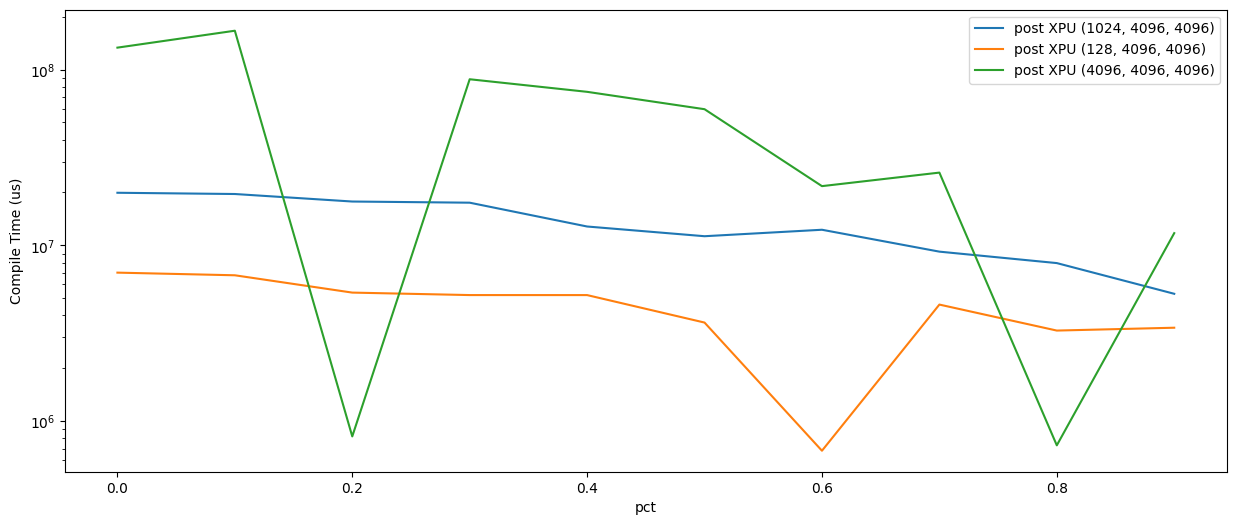

In [3]:
import matplotlib.pyplot as plt
import numpy as np    

x = keys1
xpu_y1 = [d[0] for d in xpu_data1]
xpu_y2 = [d[0] for d in xpu_data2]
xpu_y3 = [d[0] for d in xpu_data3]

# plot a line chart with common x and four lines with each y data
fig, ax = plt.subplots(figsize=(15, 6), dpi=100)
ax.plot(x, xpu_y1, label='post XPU (1024, 4096, 4096)')
ax.plot(x, xpu_y2, label='post XPU (128, 4096, 4096)')
ax.plot(x, xpu_y3, label='post XPU (4096, 4096, 4096)')

ax.set_xlabel('pct')
ax.set_ylabel('Compile Time (us)')
ax.set_yscale('log')
ax.legend()
plt.show()

## Runtime
### [k, 4096] * [4096, 4096]

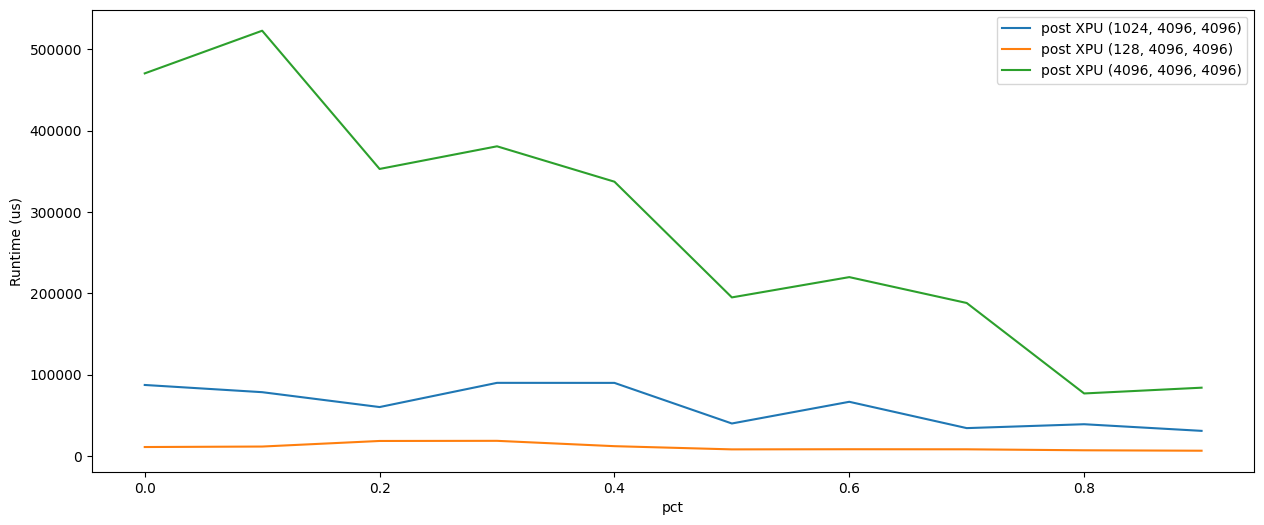

In [4]:
import matplotlib.pyplot as plt
import numpy as np

x = keys1
xpu_y1 = [d[1] for d in xpu_data1]
xpu_y2 = [d[1] for d in xpu_data2]
xpu_y3 = [d[1] for d in xpu_data3]

# plot a line chart with common x and four lines with each y data
fig, ax = plt.subplots(figsize=(15, 6), dpi=100)
ax.plot(x, xpu_y1, label='post XPU (1024, 4096, 4096)')
ax.plot(x, xpu_y2, label='post XPU (128, 4096, 4096)')
ax.plot(x, xpu_y3, label='post XPU (4096, 4096, 4096)')
ax.set_xlabel('pct')
ax.set_ylabel('Runtime (us)')
ax.legend()
plt.show()

## Throughput (TOPS)
### [k, 4096] * [4096, 4096]

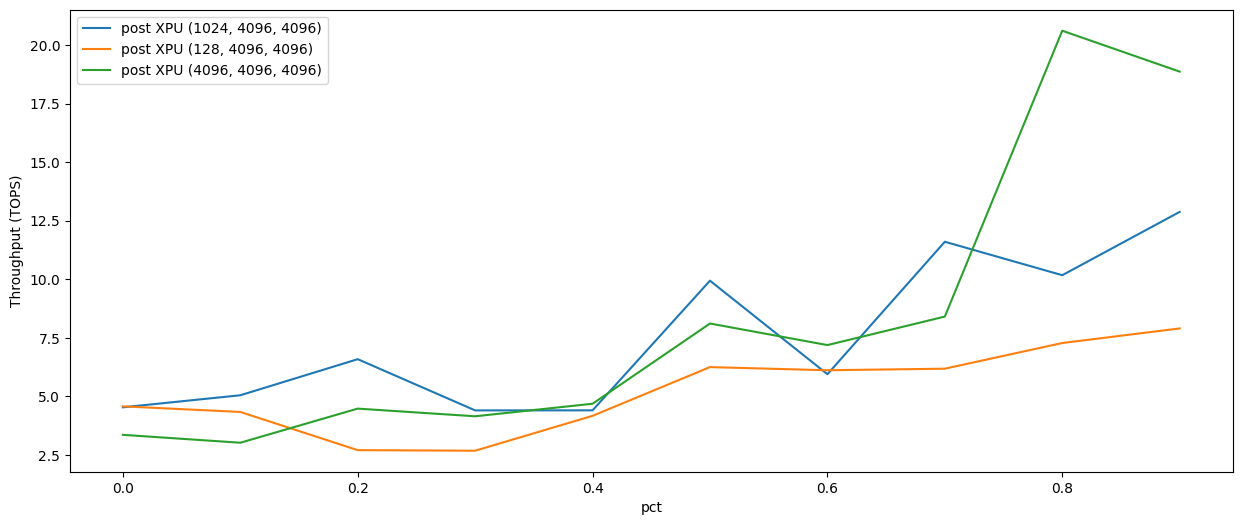

In [5]:
xpu_y1 = [d[2] for d in xpu_data1]
xpu_y2 = [d[2] for d in xpu_data2]
xpu_y3 = [d[2] for d in xpu_data3]

fig, ax = plt.subplots(figsize=(15, 6), dpi=100)
ax.plot(x, xpu_y1, label='post XPU (1024, 4096, 4096)')
ax.plot(x, xpu_y2, label='post XPU (128, 4096, 4096)')
ax.plot(x, xpu_y3, label='post XPU (4096, 4096, 4096)')

ax.set_xlabel('pct')
ax.set_ylabel('Throughput (TOPS)')
ax.legend()
plt.show()

## Bandwidth (GB/s)
### [k, 4096] * [4096, 4096]

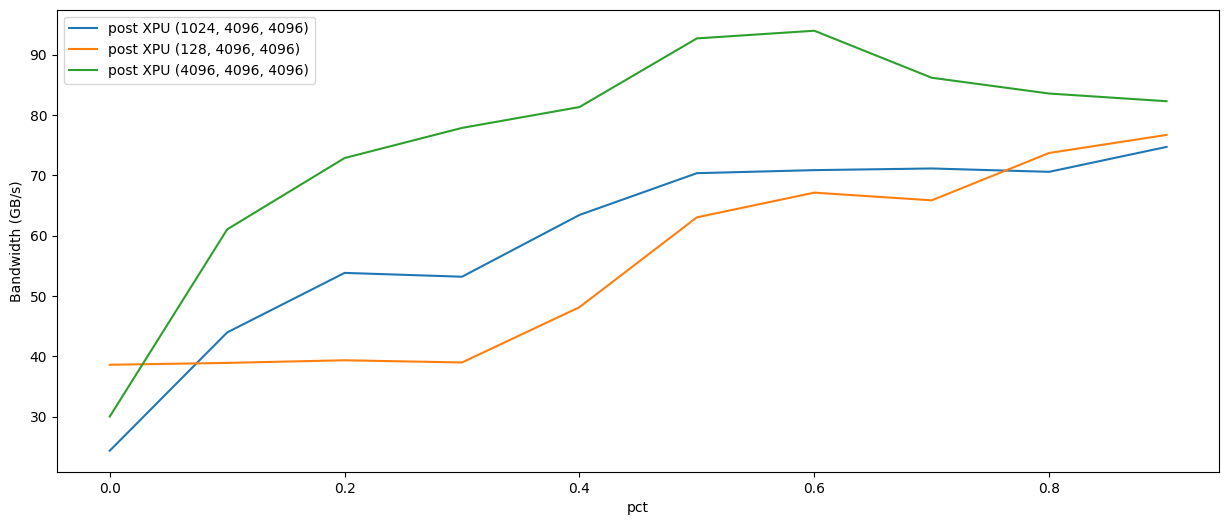

In [6]:
xpu_y1 = [d[3] for d in xpu_data1]
xpu_y2 = [d[3] for d in xpu_data2]
xpu_y3 = [d[3] for d in xpu_data3]

fig, ax = plt.subplots(figsize=(15, 6), dpi=100)
ax.plot(x, xpu_y1, label='post XPU (1024, 4096, 4096)')
ax.plot(x, xpu_y2, label='post XPU (128, 4096, 4096)')
ax.plot(x, xpu_y3, label='post XPU (4096, 4096, 4096)')

ax.set_xlabel('pct')
ax.set_ylabel('Bandwidth (GB/s)')
ax.legend()
plt.show()